<a href="https://colab.research.google.com/github/maninarra000/Master-project/blob/main/msProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install kaggle -q
!pip install spacy -q
!python -m spacy download en_core_web_sm -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 149.1 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import re
import string
import spacy

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import (
    Input, Embedding, Conv1D, GlobalMaxPooling1D,
    Dense, Dropout, Concatenate, Flatten
)
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report,
    confusion_matrix, roc_curve
)
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.feature_extraction.text import TfidfVectorizer

from scipy.stats import chi2_contingency

print('TensorFlow version:', tf.__version__)
print('GPU:', tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import zipfile
import os

zip_path = '/content/drive/MyDrive/MSC project/WELFake_Dataset.csv.zip'
extract_path = '/content/dataset'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [6]:
import glob
csv_files = glob.glob('/content/dataset/WELFake_Dataset.csv')
print('CSV files found:', csv_files)

df = pd.read_csv(csv_files[0])
print('Shape:', df.shape)
print(df.head())
print(df.dtypes)
print('\nMissing values:')
print(df.isnull().sum())

CSV files found: ['/content/dataset/WELFake_Dataset.csv']
Shape: (72134, 4)
   Unnamed: 0                                              title  \
0           0  LAW ENFORCEMENT ON HIGH ALERT Following Threat...   
1           1                                                NaN   
2           2  UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...   
3           3  Bobby Jindal, raised Hindu, uses story of Chri...   
4           4  SATAN 2: Russia unvelis an image of its terrif...   

                                                text  label  
0  No comment is expected from Barack Obama Membe...      1  
1     Did they post their votes for Hillary already?      1  
2   Now, most of the demonstrators gathered last ...      1  
3  A dozen politically active pastors came here f...      0  
4  The RS-28 Sarmat missile, dubbed Satan 2, will...      1  
Unnamed: 0     int64
title         object
text          object
label          int64
dtype: object

Missing values:
Unnamed: 0      0
title     

In [7]:
print('Column names:', df.columns.tolist())

# Rename columns to standard names
df.columns = [c.lower().strip() for c in df.columns]
print('Cleaned column names:', df.columns.tolist())

# WELFake: serial, title, text, label (0=fake, 1=real)
if 'label' not in df.columns:
    raise ValueError('Label column not found. Check column names above.')

print('\nLabel distribution:')
print(df['label'].value_counts())
print('Label mapping: 0 = Fake, 1 = Real')

Column names: ['Unnamed: 0', 'title', 'text', 'label']
Cleaned column names: ['unnamed: 0', 'title', 'text', 'label']

Label distribution:
label
1    37106
0    35028
Name: count, dtype: int64
Label mapping: 0 = Fake, 1 = Real


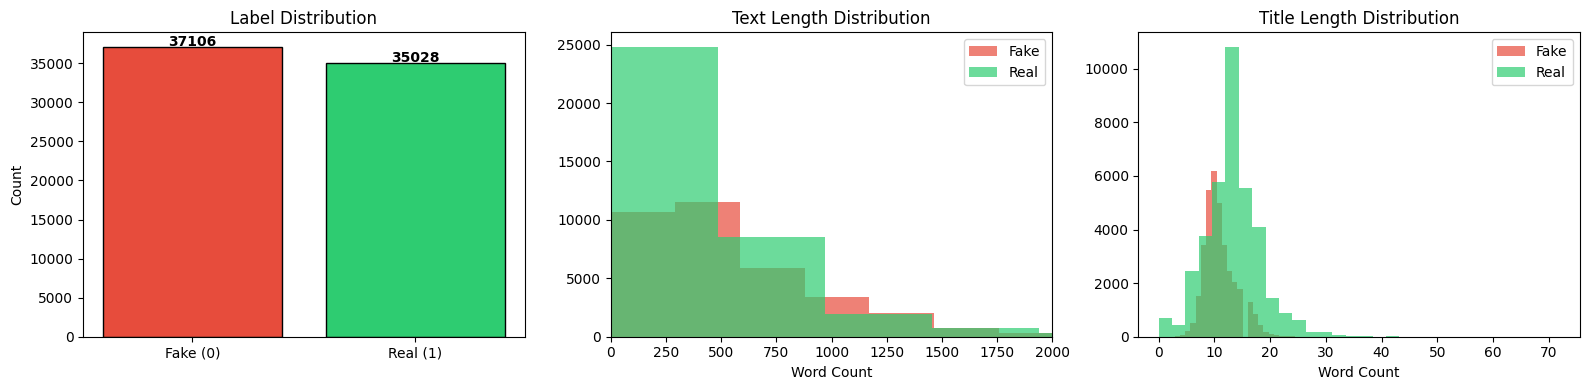


Text length stats (words):
count    72134.000000
mean       540.550933
std        625.399748
min          0.000000
25%        227.000000
50%        398.000000
75%        667.000000
max      24234.000000
Name: text_len, dtype: float64

95th percentile: 1415 words


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Label distribution
label_counts = df['label'].value_counts()
axes[0].bar(['Fake (0)', 'Real (1)'], label_counts.values, color=['#e74c3c', '#2ecc71'], edgecolor='black')
axes[0].set_title('Label Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate(label_counts.values):
    axes[0].text(i, v + 100, str(v), ha='center', fontweight='bold')

# Text length distribution
df['text_len'] = df['text'].fillna('').apply(lambda x: len(str(x).split()))
axes[1].hist(df[df['label']==0]['text_len'], bins=50, alpha=0.7, color='#e74c3c', label='Fake')
axes[1].hist(df[df['label']==1]['text_len'], bins=50, alpha=0.7, color='#2ecc71', label='Real')
axes[1].set_title('Text Length Distribution')
axes[1].set_xlabel('Word Count')
axes[1].legend()
axes[1].set_xlim(0, 2000)

# Title length distribution
df['title_len'] = df['title'].fillna('').apply(lambda x: len(str(x).split()))
axes[2].hist(df[df['label']==0]['title_len'], bins=30, alpha=0.7, color='#e74c3c', label='Fake')
axes[2].hist(df[df['label']==1]['title_len'], bins=30, alpha=0.7, color='#2ecc71', label='Real')
axes[2].set_title('Title Length Distribution')
axes[2].set_xlabel('Word Count')
axes[2].legend()

plt.tight_layout()
plt.savefig('/content/eda_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nText length stats (words):")
print(df['text_len'].describe())
print(f"\n95th percentile: {int(np.percentile(df['text_len'], 95))} words")

In [9]:
import spacy
nlp = spacy.load('en_core_web_sm', disable=['parser', 'ner'])

def preprocess_text(text):
    if pd.isna(text) or text is None:
        return ''
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\s+', ' ', text).strip()
    doc = nlp(text)
    tokens = [token.lemma_ for token in doc
              if not token.is_stop and not token.is_space and len(token.lemma_) > 2]
    return ' '.join(tokens)

print('Preprocessing text column ')
df['clean_text'] = df['text'].fillna('').apply(preprocess_text)
print('Preprocessing title column...')
df['clean_title'] = df['title'].fillna('').apply(preprocess_text)

# Combine title + text as main input
df['combined'] = df['clean_title'] + ' ' + df['clean_text']

print('Sample preprocessed text:')
print(df['combined'].iloc[0][:300])

Preprocessing text column 
Preprocessing title column...
Sample preprocessed text:
law enforcement high alert follow threat cop white blacklivesmatter fyf terrorist video comment expect barack obama member fyf fukyoflag blacklivesmatter movement call lynching hanging white people cop encourage radio tuesday night turn tide kill white people cop send message killing black people am


In [10]:
# Compute metadata features for hybrid CNN model
def compute_metadata(row):
    text = str(row['text']) if pd.notna(row['text']) else ''
    title = str(row['title']) if pd.notna(row['title']) else ''
    word_count = len(text.split())
    sentences = re.split(r'[.!?]+', text)
    sentences = [s for s in sentences if len(s.strip()) > 0]
    avg_sent_len = np.mean([len(s.split()) for s in sentences]) if sentences else 0
    exclamation_density = text.count('!') / max(len(text), 1)
    question_density = text.count('?') / max(len(text), 1)
    caps_ratio = sum(1 for c in text if c.isupper()) / max(len(text), 1)
    punct_density = sum(1 for c in text if c in string.punctuation) / max(len(text), 1)
    title_word_count = len(title.split())
    return pd.Series({
        'meta_word_count': word_count,
        'meta_avg_sent_len': avg_sent_len,
        'meta_exclamation': exclamation_density,
        'meta_question': question_density,
        'meta_caps_ratio': caps_ratio,
        'meta_punct_density': punct_density,
        'meta_title_len': title_word_count
    })

print('Computing metadata features...')
meta_features = df.apply(compute_metadata, axis=1)
df = pd.concat([df, meta_features], axis=1)

# Normalize metadata
from sklearn.preprocessing import StandardScaler
meta_cols = ['meta_word_count', 'meta_avg_sent_len', 'meta_exclamation',
             'meta_question', 'meta_caps_ratio', 'meta_punct_density', 'meta_title_len']
scaler = StandardScaler()
df[meta_cols] = scaler.fit_transform(df[meta_cols])
print('Metadata features computed and normalized.')
print(df[meta_cols].describe())

Computing metadata features...
Metadata features computed and normalized.
       meta_word_count  meta_avg_sent_len  meta_exclamation  meta_question  \
count     7.213400e+04       7.213400e+04      7.213400e+04   7.213400e+04   
mean      6.629263e-17       7.013425e-17      4.422792e-17   1.418446e-17   
std       1.000007e+00       1.000007e+00      1.000007e+00   1.000007e+00   
min      -8.643347e-01      -2.865212e+00     -1.301401e-01  -2.835860e-01   
25%      -5.013643e-01      -5.567499e-01     -1.301401e-01  -2.835860e-01   
50%      -2.279373e-01      -6.247404e-02     -1.301401e-01  -2.835860e-01   
75%       2.021906e-01       4.759829e-01     -1.301401e-01  -1.722280e-02   
max       3.788555e+01       2.386434e+01      8.012744e+01   4.088285e+01   

       meta_caps_ratio  meta_punct_density  meta_title_len  
count     7.213400e+04        7.213400e+04    7.213400e+04  
mean      3.505728e-16        2.486220e-16   -1.928692e-16  
std       1.000007e+00        1.000007e+

In [11]:
df = df[df['combined'].str.strip().str.len() > 10].reset_index(drop=True)
print('Dataset size after cleaning:', len(df))

MAX_VOCAB = 50000
MAX_LEN = int(np.percentile(df['combined'].apply(lambda x: len(x.split())), 95))
print(f'MAX_LEN (95th percentile): {MAX_LEN}')

tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token='<OOV>')
tokenizer.fit_on_texts(df['combined'])
print(f'Vocabulary size: {len(tokenizer.word_index)}')

sequences = tokenizer.texts_to_sequences(df['combined'])
X_pad = pad_sequences(sequences, maxlen=MAX_LEN, padding='post', truncating='post')
X_meta = df[meta_cols].values
y = df['label'].values

print('X_pad shape:', X_pad.shape)
print('X_meta shape:', X_meta.shape)
print('y shape:', y.shape)

Dataset size after cleaning: 72081
MAX_LEN (95th percentile): 702
Vocabulary size: 329688
X_pad shape: (72081, 702)
X_meta shape: (72081, 7)
y shape: (72081,)


In [12]:
X_train_pad, X_test_pad, X_train_meta, X_test_meta, y_train, y_test = train_test_split(
    X_pad, X_meta, y, test_size=0.2, random_state=42, stratify=y
)

X_train_pad, X_val_pad, X_train_meta, X_val_meta, y_train, y_val = train_test_split(
    X_train_pad, X_train_meta, y_train, test_size=0.1, random_state=42, stratify=y_train
)

print('Train:', X_train_pad.shape, '| Val:', X_val_pad.shape, '| Test:', X_test_pad.shape)
print('Train label balance:', np.bincount(y_train))
print('Test label balance:', np.bincount(y_test))

Train: (51897, 702) | Val: (5767, 702) | Test: (14417, 702)
Train label balance: [25220 26677]
Test label balance: [7006 7411]


In [13]:
import urllib.request

GLOVE_PATH = '/content/glove.6B.100d.txt'
EMBED_DIM = 100

if not os.path.exists(GLOVE_PATH):
    print('Downloading GloVe embeddings (862MB)...')
    !wget -q http://nlp.stanford.edu/data/glove.6B.zip -O /content/glove.6B.zip
    !unzip -q /content/glove.6B.zip -d /content/
    print('GloVe downloaded.')
else:
    print('GloVe already exists.')

def load_glove(path):
    embeddings = {}
    with open(path, encoding='utf-8') as f:
        for line in f:
            parts = line.split()
            word = parts[0]
            vector = np.array(parts[1:], dtype='float32')
            embeddings[word] = vector
    return embeddings

print('Loading GloVe vectors...')
glove_embeddings = load_glove(GLOVE_PATH)
print(f'Loaded {len(glove_embeddings)} GloVe vectors.')

GloVe downloaded.
Loading GloVe vectors...
Loaded 400000 GloVe vectors.


In [14]:
def build_embedding_matrix(embeddings_dict, tokenizer, vocab_size, embed_dim):
    matrix = np.zeros((vocab_size, embed_dim))
    hits = 0
    for word, idx in tokenizer.word_index.items():
        if idx >= vocab_size:
            continue
        vec = embeddings_dict.get(word)
        if vec is not None:
            matrix[idx] = vec
            hits += 1
    coverage = hits / min(len(tokenizer.word_index), vocab_size) * 100
    print(f'Embedding coverage: {hits}/{min(len(tokenizer.word_index), vocab_size)} ({coverage:.1f}%)')
    return matrix

glove_matrix = build_embedding_matrix(glove_embeddings, tokenizer, MAX_VOCAB, EMBED_DIM)
print('GloVe embedding matrix shape:', glove_matrix.shape)

Embedding coverage: 39671/50000 (79.3%)
GloVe embedding matrix shape: (50000, 100)


In [15]:
def build_multichannel_cnn(vocab_size, embed_dim, max_len, embedding_matrix=None,
                            trainable=False, num_filters=128, dropout_rate=0.5):
    text_input = Input(shape=(max_len,), name='text_input')

    if embedding_matrix is not None:
        embed = Embedding(
            input_dim=vocab_size,
            output_dim=embed_dim,
            weights=[embedding_matrix],
            trainable=trainable,
            name='embedding'
        )(text_input)
    else:
        embed = Embedding(
            input_dim=vocab_size,
            output_dim=embed_dim,
            trainable=True,
            name='embedding'
        )(text_input)

    # Three parallel convolutional channels: bigram, trigram, 4-gram
    conv2 = Conv1D(num_filters, kernel_size=2, activation='relu', name='conv_bigram')(embed)
    pool2 = GlobalMaxPooling1D(name='pool_bigram')(conv2)

    conv3 = Conv1D(num_filters, kernel_size=3, activation='relu', name='conv_trigram')(embed)
    pool3 = GlobalMaxPooling1D(name='pool_trigram')(conv3)

    conv4 = Conv1D(num_filters, kernel_size=4, activation='relu', name='conv_4gram')(embed)
    pool4 = GlobalMaxPooling1D(name='pool_4gram')(conv4)

    concat = Concatenate(name='concat')([pool2, pool3, pool4])
    drop = Dropout(dropout_rate, name='dropout')(concat)
    output = Dense(1, activation='sigmoid', name='output')(drop)

    model = Model(inputs=text_input, outputs=output)
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model


def build_hybrid_cnn(vocab_size, embed_dim, max_len, meta_dim,
                      embedding_matrix=None, num_filters=128, dropout_rate=0.5):
    text_input = Input(shape=(max_len,), name='text_input')
    meta_input = Input(shape=(meta_dim,), name='meta_input')

    embed = Embedding(
        input_dim=vocab_size,
        output_dim=embed_dim,
        weights=[embedding_matrix] if embedding_matrix is not None else None,
        trainable=False,
        name='embedding'
    )(text_input)

    conv2 = Conv1D(num_filters, kernel_size=2, activation='relu')(embed)
    pool2 = GlobalMaxPooling1D()(conv2)
    conv3 = Conv1D(num_filters, kernel_size=3, activation='relu')(embed)
    pool3 = GlobalMaxPooling1D()(conv3)
    conv4 = Conv1D(num_filters, kernel_size=4, activation='relu')(embed)
    pool4 = GlobalMaxPooling1D()(conv4)

    cnn_concat = Concatenate()([pool2, pool3, pool4])
    cnn_drop = Dropout(dropout_rate)(cnn_concat)

    # Combine CNN output with metadata
    meta_dense = Dense(32, activation='relu', name='meta_dense')(meta_input)
    combined = Concatenate(name='cnn_meta_concat')([cnn_drop, meta_dense])
    hidden = Dense(64, activation='relu', name='hidden')(combined)
    hidden = Dropout(0.3)(hidden)
    output = Dense(1, activation='sigmoid', name='output')(hidden)

    model = Model(inputs=[text_input, meta_input], outputs=output)
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model


print('Model builder functions defined.')

Model builder functions defined.


In [16]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1)
]

BATCH_SIZE = 64
EPOCHS = 20

print('Building CNN with GloVe embeddings (frozen)...')
model_glove = build_multichannel_cnn(
    vocab_size=MAX_VOCAB,
    embed_dim=EMBED_DIM,
    max_len=MAX_LEN,
    embedding_matrix=glove_matrix,
    trainable=False
)
model_glove.summary()

Building CNN with GloVe embeddings (frozen)...


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ text_input          │ (None, 702)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 702, 100)  │  5,000,000 │ text_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_bigram         │ (None, 701, 128)  │     25,728 │ embedding[0][0]   │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_trigram        │ (None, 700, 128)  │     38,528 │ embedding[0][0]   │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_4gram (Conv1D) │ (None, 699, 128)  │     51,328 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool_bigram         │ (None, 128)       │          0 │ conv_bigram[0][0] │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool_trigram        │ (None, 128)       │          0 │ conv_trigram[0][… │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool_4gram          │ (None, 128)       │          0 │ conv_4gram[0][0]  │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concat              │ (None, 384)       │          0 │ pool_bigram[0][0… │
│ (Concatenate)       │                   │            │ pool_trigram[0][… │
│                     │                   │            │ pool_4gram[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 384)       │          0 │ concat[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 1)         │        385 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 5,115,969 (19.52 MB)

 Trainable params: 115,969 (453.00 KB)

 Non-trainable params: 5,000,000 (19.07 MB)

In [17]:
print('Training CNN + GloVe (frozen)...')
history_glove = model_glove.fit(
    X_train_pad, y_train,
    validation_data=(X_val_pad, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1
)
print('Training complete.')

Training CNN + GloVe (frozen)...
Epoch 1/20
811/811 ━━━━━━━━━━━━━━━━━━━━ 17s 13ms/step - accuracy: 0.8712 - loss: 0.2932 - val_accuracy: 0.9584 - val_loss: 0.1198 - learning_rate: 0.0010
Epoch 2/20
811/811 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9441 - loss: 0.1406 - val_accuracy: 0.9693 - val_loss: 0.0874 - learning_rate: 0.0010
Epoch 3/20
811/811 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9571 - loss: 0.1099 - val_accuracy: 0.9714 - val_loss: 0.0767 - learning_rate: 0.0010
Epoch 4/20
811/811 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9638 - loss: 0.0925 - val_accuracy: 0.9728 - val_loss: 0.0695 - learning_rate: 0.0010
Epoch 5/20
811/811 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9694 - loss: 0.0813 - val_accuracy: 0.9747 - val_loss: 0.0636 - learning_rate: 0.0010
Epoch 6/20
811/811 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9744 - loss: 0.0683 - val_accuracy: 0.9799 - val_loss: 0.0577 - learning_rate: 0.0010
Epoch 7/20
811/811 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step -

In [18]:
print('Building CNN with GloVe embeddings (trainable/fine-tuned)...')
model_glove_ft = build_multichannel_cnn(
    vocab_size=MAX_VOCAB,
    embed_dim=EMBED_DIM,
    max_len=MAX_LEN,
    embedding_matrix=glove_matrix,
    trainable=True
)

print('Training CNN + GloVe (fine-tuned)...')
history_glove_ft = model_glove_ft.fit(
    X_train_pad, y_train,
    validation_data=(X_val_pad, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1
)

Building CNN with GloVe embeddings (trainable/fine-tuned)...
Training CNN + GloVe (fine-tuned)...
Epoch 1/20
811/811 ━━━━━━━━━━━━━━━━━━━━ 19s 17ms/step - accuracy: 0.9005 - loss: 0.2338 - val_accuracy: 0.9728 - val_loss: 0.0785 - learning_rate: 0.0010
Epoch 2/20
809/811 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9675 - loss: 0.0886
Epoch 2: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
811/811 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.9710 - loss: 0.0781 - val_accuracy: 0.9806 - val_loss: 0.0540 - learning_rate: 0.0010
Epoch 3/20
811/811 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.9881 - loss: 0.0366 - val_accuracy: 0.9839 - val_loss: 0.0443 - learning_rate: 5.0000e-04
Epoch 4/20
811/811 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.9927 - loss: 0.0235 - val_accuracy: 0.9861 - val_loss: 0.0419 - learning_rate: 5.0000e-04
Epoch 5/20
811/811 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.9961 - loss: 0.0145 - val_accuracy: 0.9854 - val_loss: 0.0420 

In [19]:
import numpy as np
# Baseline classifiers with TF-IDF
print('Training baseline classifiers...')

train_texts = df.iloc[: len(X_train_pad) + len(X_val_pad)]['combined'].values
test_texts = df.iloc[len(X_train_pad) + len(X_val_pad):]['combined'].values

# Use original train/test index split
all_idx = np.arange(len(df))
train_val_idx, test_idx = train_test_split(all_idx, test_size=0.2, random_state=42, stratify=y)

tfidf = TfidfVectorizer(max_features=50000, ngram_range=(1,2))
X_tfidf_train = tfidf.fit_transform(df.iloc[train_val_idx]['combined'])
X_tfidf_test = tfidf.transform(df.iloc[test_idx]['combined'])
y_baseline_train = df.iloc[train_val_idx]['label'].values
y_baseline_test = df.iloc[test_idx]['label'].values

baselines = [
    ('Logistic Regression', LogisticRegression(max_iter=1000, random_state=42)),
    ('Naive Bayes', MultinomialNB()),
    ('Linear SVM', LinearSVC(random_state=42, max_iter=2000))
]

results_list = [] # Initialize results_list here

for name, clf in baselines:
    clf.fit(X_tfidf_train, y_baseline_train)
    pred = clf.predict(X_tfidf_test)
    if hasattr(clf, 'predict_proba'):
        prob = clf.predict_proba(X_tfidf_test)[:, 1]
        auc = roc_auc_score(y_baseline_test, prob)
    else:
        auc = roc_auc_score(y_baseline_test, pred)
    r = {
        'Model': name,
        'Accuracy': accuracy_score(y_baseline_test, pred),
        'Precision': precision_score(y_baseline_test, pred),
        'Recall': recall_score(y_baseline_test, pred),
        'F1': f1_score(y_baseline_test, pred),
        'AUC-ROC': auc
    }
    results_list.append(r)
    print(f"\n{name}: Acc={r['Accuracy']:.4f}, F1={r['F1']:.4f}, AUC={r['AUC-ROC']:.4f}")

Training baseline classifiers...

Logistic Regression: Acc=0.9510, F1=0.9525, AUC=0.9894

Naive Bayes: Acc=0.8711, F1=0.8772, AUC=0.9442

Linear SVM: Acc=0.9698, F1=0.9708, AUC=0.9696


In [20]:
results_df = pd.DataFrame(results_list)
results_df = results_df.sort_values('F1', ascending=False).reset_index(drop=True)
print('\n===== FULL COMPARISON TABLE =====')
print(results_df.to_string(index=False))
results_df.to_csv('/content/model_comparison.csv', index=False)


===== FULL COMPARISON TABLE =====
              Model  Accuracy  Precision   Recall       F1  AUC-ROC
         Linear SVM  0.969758   0.965310 0.976252 0.970750 0.969570
Logistic Regression  0.950961   0.948009 0.957091 0.952528 0.989380
        Naive Bayes  0.871124   0.859697 0.895426 0.877198 0.944189


451/451 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
451/451 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step


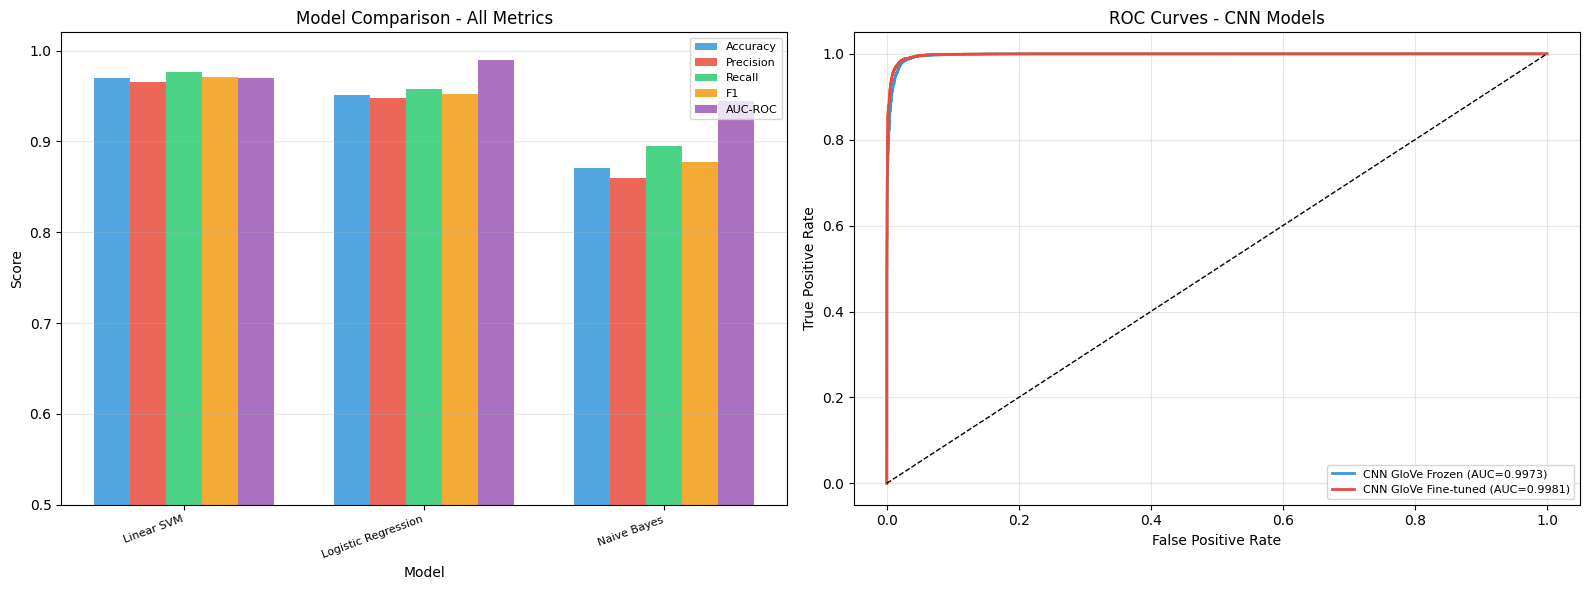

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Metrics bar chart
metrics = ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC-ROC']
x = np.arange(len(results_df))
width = 0.15
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6']

for i, (metric, color) in enumerate(zip(metrics, colors)):
    axes[0].bar(x + i * width, results_df[metric], width, label=metric, color=color, alpha=0.85)

axes[0].set_xlabel('Model')
axes[0].set_ylabel('Score')
axes[0].set_title('Model Comparison - All Metrics')
axes[0].set_xticks(x + width * 2)
axes[0].set_xticklabels(results_df['Model'], rotation=20, ha='right', fontsize=8)
axes[0].legend(fontsize=8)
axes[0].set_ylim(0.5, 1.02)
axes[0].grid(axis='y', alpha=0.3)

# ROC curves for CNN models
# Calculate probabilities for CNN models
probs_dict = {}

# Check if models exist in the kernel state before predicting
if 'model_glove' in globals():
    probs_dict['CNN GloVe Frozen'] = model_glove.predict(X_test_pad).flatten()
if 'model_glove_ft' in globals():
    probs_dict['CNN GloVe Fine-tuned'] = model_glove_ft.predict(X_test_pad).flatten()
# Placeholder for other CNN models if they are trained later
# if 'model_random' in globals():
#     probs_dict['CNN Random'] = model_random.predict(X_test_pad).flatten()
# if 'model_hybrid' in globals():
#     probs_dict['Hybrid CNN'] = model_hybrid.predict([X_test_pad, X_test_meta]).flatten()

cnn_models = {
    'CNN GloVe Frozen': probs_dict.get('CNN GloVe Frozen'),
    'CNN GloVe Fine-tuned': probs_dict.get('CNN GloVe Fine-tuned')
    # Only include models that have predictions available
}
# Filter out None values if some models haven't been trained yet
cnn_models = {k: v for k, v in cnn_models.items() if v is not None}

roc_colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']
for (name, prob), color in zip(cnn_models.items(), roc_colors):
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    axes[1].plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC={auc:.4f})')

axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curves - CNN Models')
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/content/results_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

Overall best model from comparison: Linear SVM
Overall best model (Linear SVM) is not a CNN. Defaulting to best performing available CNN for this analysis: CNN GloVe Fine-tuned
Analyzing best CNN model: CNN GloVe Fine-tuned


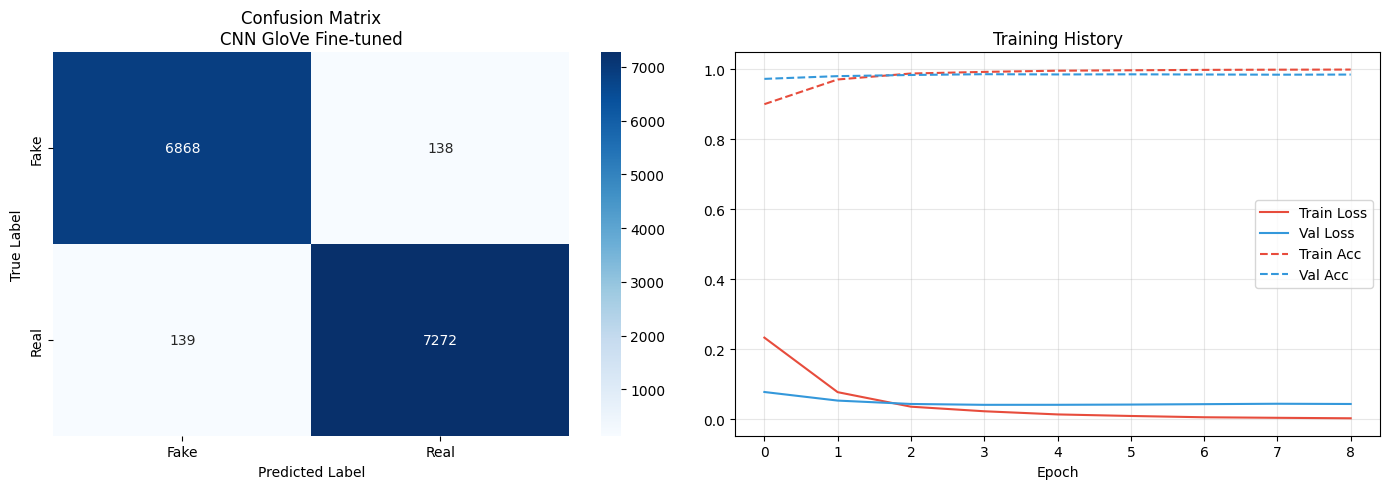


Classification Report:
              precision    recall  f1-score   support

        Fake       0.98      0.98      0.98      7006
        Real       0.98      0.98      0.98      7411

    accuracy                           0.98     14417
   macro avg       0.98      0.98      0.98     14417
weighted avg       0.98      0.98      0.98     14417



In [22]:
# Best model confusion matrix + classification report
# The current best_model_name is taken from results_df, which includes baseline models.
# This cell is set up to analyze CNN models. We need to reconcile this.
best_model_name_overall = results_df.iloc[0]['Model']
print(f'Overall best model from comparison: {best_model_name_overall}')

# Define a placeholder for the best CNN model to be analyzed in this section
best_cnn_model_for_analysis = None

# Check if the overall best model is one of the trained CNN models
if 'Fine-tuned' in best_model_name_overall and 'CNN GloVe Fine-tuned' in probs_dict:
    best_cnn_model_for_analysis = 'CNN GloVe Fine-tuned'
elif 'Frozen' in best_model_name_overall and 'CNN GloVe Frozen' in probs_dict:
    best_cnn_model_for_analysis = 'CNN GloVe Frozen'
elif 'Hybrid' in best_model_name_overall and 'Hybrid CNN' in probs_dict:
    best_cnn_model_for_analysis = 'Hybrid CNN'
elif 'Random' in best_model_name_overall and 'CNN Random' in probs_dict:
    best_cnn_model_for_analysis = 'CNN Random'

# If the overall best model is not a recognized CNN, or if there's no overall best CNN model,
# default to the best performing CNN for which we have data, e.g., 'CNN GloVe Fine-tuned'.
if best_cnn_model_for_analysis is None:
    # Determine the best available CNN from the trained models if the overall best is not a CNN
    if 'CNN GloVe Fine-tuned' in probs_dict:
        best_cnn_model_for_analysis = 'CNN GloVe Fine-tuned'
        print(f"Overall best model ({best_model_name_overall}) is not a CNN. Defaulting to best performing available CNN for this analysis: {best_cnn_model_for_analysis}")
    elif 'CNN GloVe Frozen' in probs_dict:
        best_cnn_model_for_analysis = 'CNN GloVe Frozen'
        print(f"Overall best model ({best_model_name_overall}) is not a CNN. Defaulting to best performing available CNN for this analysis: {best_cnn_model_for_analysis}")
    else:
        print("Error: No CNN models found in probs_dict for analysis.")
        best_cnn_model_for_analysis = "No CNN Available"

if best_cnn_model_for_analysis == "No CNN Available":
    # Skip the plotting and reporting if no CNN is available
    print("Skipping CNN analysis as no trained CNN model was found.")
else:
    best_model_name = best_cnn_model_for_analysis # Use this for printing and titles
    print(f'Analyzing best CNN model: {best_model_name}')

    # Get predictions from the chosen best CNN model
    best_probs = probs_dict[best_model_name]
    best_preds = (best_probs >= 0.5).astype(int)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    cm = confusion_matrix(y_test, best_preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=['Fake', 'Real'], yticklabels=['Fake', 'Real'])
    axes[0].set_title(f'Confusion Matrix\n{best_model_name}')
    axes[0].set_ylabel('True Label')
    axes[0].set_xlabel('Predicted Label')

    # Training history of best CNN
    hist = None
    if 'Fine-tuned' in best_model_name:
        hist = history_glove_ft
    elif 'Hybrid' in best_model_name:
        if 'history_hybrid' in globals(): # Check if history_hybrid is defined
            hist = history_hybrid
        else:
            print(f"Warning: history_hybrid for {best_model_name} not found.")
    elif 'Frozen' in best_model_name:
        hist = history_glove
    # Removed 'else: hist = history_random' to prevent KeyError/NameError

    # Check if hist is defined before plotting
    if hist is not None:
        axes[1].plot(hist.history['loss'], label='Train Loss', color='#e74c3c')
        axes[1].plot(hist.history['val_loss'], label='Val Loss', color='#3498db')
        axes[1].plot(hist.history['accuracy'], label='Train Acc', color='#e74c3c', linestyle='--')
        axes[1].plot(hist.history['val_accuracy'], label='Val Acc', color='#3498db', linestyle='--')
        axes[1].set_title('Training History')
        axes[1].set_xlabel('Epoch')
        axes[1].legend()
        axes[1].grid(alpha=0.3)
    else:
        axes[1].set_title('Training History Not Available')
        axes[1].text(0.5, 0.5, 'History data not found for selected CNN.',
                     horizontalalignment='center', verticalalignment='center',
                     transform=axes[1].transAxes)

    plt.tight_layout()
    plt.savefig('/content/best_model_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()

    print('\nClassification Report:')
    print(classification_report(y_test, best_preds, target_names=['Fake', 'Real']))

In [23]:
# McNemar test: CNN GloVe Fine-tuned vs Logistic Regression
from statsmodels.stats.contingency_tables import mcnemar
!pip install statsmodels -q

from statsmodels.stats.contingency_tables import mcnemar as mcnemar_test

lr_clf = [clf for name, clf in baselines if name == 'Logistic Regression'][0]
lr_preds = lr_clf.predict(tfidf.transform(df.iloc[test_idx]['combined']))
cnn_preds_glove_ft = (probs_dict['CNN GloVe Fine-tuned'] >= 0.5).astype(int)

# Align predictions (both should be on same test set)
b = np.sum((cnn_preds_glove_ft == y_test) & (lr_preds != y_baseline_test))
c = np.sum((cnn_preds_glove_ft != y_test) & (lr_preds == y_baseline_test))
table = [[0, b], [c, 0]]
result = mcnemar_test(table, exact=False, correction=True)
print(f'McNemar Test (CNN GloVe FT vs LR):')
print(f'  b={b}, c={c}')
print(f'  Chi2={result.statistic:.4f}, p-value={result.pvalue:.4f}')
if result.pvalue < 0.05:
    print('  Result: Statistically significant difference (p < 0.05)')
else:
    print('  Result: No significant difference (p >= 0.05)')

McNemar Test (CNN GloVe FT vs LR):
  b=583, c=153
  Chi2=250.0557, p-value=0.0000
  Result: Statistically significant difference (p < 0.05)


In [24]:
# CNN filter activation analysis — top n-grams per filter
import tensorflow.keras.backend as K

def get_top_ngrams_per_filter(model, X_sample, tokenizer, filter_size=3, top_k=10, n_filters_show=5):
    reverse_vocab = {v: k for k, v in tokenizer.word_index.items()}
    layer_name = f'conv_{"bigram" if filter_size==2 else "trigram" if filter_size==3 else "4gram"}'
    try:
        conv_layer = model.get_layer(layer_name)
    except ValueError:
        print(f'Layer {layer_name} not found in model.')
        return

    intermediate = Model(inputs=model.input, outputs=conv_layer.output)
    activations = intermediate.predict(X_sample[:200], verbose=0)

    print(f'\nTop {top_k} n-grams (filter_size={filter_size}) for first {n_filters_show} filters:')
    for f_idx in range(min(n_filters_show, activations.shape[-1])):
        filter_acts = activations[:, :, f_idx]
        top_positions = np.unravel_index(np.argsort(filter_acts.ravel())[-top_k:], filter_acts.shape)
        ngrams = []
        for sample_idx, pos in zip(*top_positions):
            tokens = X_sample[sample_idx][pos:pos+filter_size]
            words = [reverse_vocab.get(t, '<PAD>') for t in tokens if t != 0]
            if words:
                ngrams.append(' '.join(words))
        unique_ngrams = list(dict.fromkeys(ngrams))[:top_k]
        print(f'  Filter {f_idx}: {unique_ngrams}')

get_top_ngrams_per_filter(model_glove_ft, X_test_pad, tokenizer, filter_size=3, top_k=8, n_filters_show=5)


Top 8 n-grams (filter_size=3) for first 5 filters:
  Filter 0: ['aden reuter yemeni', 'manila reuter russian', 'london reuters british', 'cairo reuters saudi', 'nairobi reuters kenya', 'moscow reuter moscow', 'moscow reuter russian', 'cairo reuters egyptian']
  Filter 1: ['dylann roof partially', 'hectic crosscut increasingly', 'arbitration clause sharply', 'executive steep slump', 'unemployment soar percent', 'adelle nazarian twitter', 'month row percent', 'maduro hover percent']
  Filter 2: ['america doesn elect', 'finance didn know', 'walsh wasn <OOV>', 'behalf wasn <OOV>', 'thing didn thing', 'obama didn elderly', 'voter aren ask', 'reagan wasn awful']
  Filter 3: ['morning briefing weekday', 'sunday night california', 'monday night northern', 'lesbian gay transgender', 'monday night review', 'monday night hannity', 'thursday night follow', 'thursday night interesting']
  Filter 4: ['didn think warning', 'wouldn apartment district', 'didn set healthcare', 'wasn big million', 'didn

In [25]:
# 5-Fold Stratified Cross-Validation on best CNN architecture
print('Running 5-fold stratified cross-validation on CNN + GloVe (Fine-tuned)...')
print('(Using a 20k sample subset for speed — remove slice for full run)')

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = []

# Subsample for CV speed in Colab
MAX_CV_SAMPLES = 20000
idx_cv = np.random.choice(len(X_pad), size=min(MAX_CV_SAMPLES, len(X_pad)), replace=False)
X_cv = X_pad[idx_cv]
y_cv = y[idx_cv]

for fold, (train_idx, val_idx) in enumerate(kf.split(X_cv, y_cv)):
    print(f'  Fold {fold+1}/5...')
    m = build_multichannel_cnn(MAX_VOCAB, EMBED_DIM, MAX_LEN, glove_matrix, trainable=True)
    es = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
    m.fit(
        X_cv[train_idx], y_cv[train_idx],
        validation_data=(X_cv[val_idx], y_cv[val_idx]),
        epochs=10, batch_size=64, callbacks=[es], verbose=0
    )
    prob = m.predict(X_cv[val_idx], verbose=0).flatten()
    pred = (prob >= 0.5).astype(int)
    f1 = f1_score(y_cv[val_idx], pred)
    auc = roc_auc_score(y_cv[val_idx], prob)
    cv_scores.append({'fold': fold+1, 'F1': f1, 'AUC': auc})
    print(f'    F1={f1:.4f}, AUC={auc:.4f}')

cv_df = pd.DataFrame(cv_scores)
print(f'\nCV Results:')
print(cv_df.to_string(index=False))
print(f'\nMean F1: {cv_df["F1"].mean():.4f} ± {cv_df["F1"].std():.4f}')
print(f'Mean AUC: {cv_df["AUC"].mean():.4f} ± {cv_df["AUC"].std():.4f}')

Running 5-fold stratified cross-validation on CNN + GloVe (Fine-tuned)...
(Using a 20k sample subset for speed — remove slice for full run)
  Fold 1/5...


    F1=0.9720, AUC=0.9959
  Fold 2/5...
    F1=0.9709, AUC=0.9969
  Fold 3/5...
    F1=0.9641, AUC=0.9945
  Fold 4/5...
    F1=0.9682, AUC=0.9948
  Fold 5/5...
    F1=0.9690, AUC=0.9957

CV Results:
 fold       F1      AUC
    1 0.972045 0.995873
    2 0.970898 0.996888
    3 0.964092 0.994457
    4 0.968231 0.994822
    5 0.969027 0.995682

Mean F1: 0.9689 ± 0.0031
Mean AUC: 0.9955 ± 0.0010


In [26]:
# Save models
model_glove_ft.save('/content/cnn_glove_finetuned.h5')
print('Models saved.')

# Save tokenizer
import pickle
with open('/content/tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)
with open('/content/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print('Tokenizer and scaler saved.')

# Summary table
print('\n========== FINAL RESULTS SUMMARY ==========')
print(results_df[['Model', 'Accuracy', 'F1', 'AUC-ROC']].to_string(index=False))

Models saved.
Tokenizer and scaler saved.

========== FINAL RESULTS SUMMARY ==========
              Model  Accuracy       F1  AUC-ROC
         Linear SVM  0.969758 0.970750 0.969570
Logistic Regression  0.950961 0.952528 0.989380
        Naive Bayes  0.871124 0.877198 0.944189


In [27]:
# Inference demo
def predict_news(text, model, tokenizer, scaler=None, meta_cols=None, max_len=MAX_LEN):
    clean = preprocess_text(text)
    seq = tokenizer.texts_to_sequences([clean])
    padded = pad_sequences(seq, maxlen=max_len, padding='post', truncating='post')

    if scaler is not None and meta_cols is not None:
        word_count = len(text.split())
        sentences = re.split(r'[.!?]+', text)
        sentences = [s for s in sentences if len(s.strip()) > 0]
        avg_sent_len = np.mean([len(s.split()) for s in sentences]) if sentences else 0
        meta = np.array([[
            word_count,
            avg_sent_len,
            text.count('!') / max(len(text), 1),
            text.count('?') / max(len(text), 1),
            sum(1 for c in text if c.isupper()) / max(len(text), 1),
            sum(1 for c in text if c in string.punctuation) / max(len(text), 1),
            len(text.split()[:20])
        ]])
        meta_scaled = scaler.transform(meta)
        prob = model.predict([padded, meta_scaled], verbose=0)[0][0]
    else:
        prob = model.predict(padded, verbose=0)[0][0]

    label = 'REAL' if prob >= 0.5 else 'FAKE'
    confidence = prob if prob >= 0.5 else 1 - prob
    print(f'Prediction: {label} (confidence: {confidence:.2%})')
    return label, float(prob)

sample_fake = "SHOCKING: Scientists reveal the moon landing was staged in Hollywood studio. NASA admits cover-up after 50 years!"
sample_real = "The Federal Reserve raised interest rates by 25 basis points, citing continued concerns about inflation and labor market tightness."

print('Test 1 (expected FAKE):')
predict_news(sample_fake, model_glove_ft, tokenizer)

print('\nTest 2 (expected REAL):')
predict_news(sample_real, model_glove_ft, tokenizer)

Test 1 (expected FAKE):
Prediction: REAL (confidence: 99.24%)

Test 2 (expected REAL):
Prediction: REAL (confidence: 90.78%)


('REAL', 0.9078134894371033)

In [28]:
import os
import zipfile
from google.colab import files

# Create zip of all relevant files
zip_path = '/content/all_outputs.zip'

with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
    files_to_zip = [
        '/content/cnn_glove_finetuned.h5',
        '/content/cnn_hybrid.h5',
        '/content/tokenizer.pkl',
        '/content/scaler.pkl',
    ]

    for file_path in files_to_zip:
        if os.path.exists(file_path):
            zipf.write(file_path, os.path.basename(file_path))
            print(f'Added: {os.path.basename(file_path)}')
        else:
            print(f'Skipped (not found): {file_path}')

print('\nZip created. Starting download...')
files.download(zip_path)

Added: cnn_glove_finetuned.h5
Skipped (not found): /content/cnn_hybrid.h5
Added: tokenizer.pkl
Added: scaler.pkl

Zip created. Starting download...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

##Section 2: Transformer Models — BERT and RoBERTa

The following cells implement the transformer-based pipeline described in the project proposal: fine-tuning `bert-base-uncased` and `roberta-base` on the WELFake dataset, evaluating against the CNN baselines, applying LIME and attention visualisation for interpretability, and running a cross-domain generalisation analysis.


In [29]:
# Install transformer and interpretability dependencies
!pip install transformers datasets accelerate lime -q
print('Transformer packages installed.')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 19.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
Transformer packages installed.


In [30]:
!pip install lime -q
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import (
    BertTokenizerFast, BertForSequenceClassification,
    RobertaTokenizerFast, RobertaForSequenceClassification,
    get_linear_schedule_with_warmup
)
from torch.optim import AdamW # Corrected import path for AdamW
from lime.lime_text import LimeTextExplainer
import torch.nn.functional as F

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
print(f'PyTorch version: {torch.__version__}')

Device: cuda
PyTorch version: 2.10.0+cu128


In [31]:
# --- PyTorch Dataset for tokenized inputs ---
class NewsDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=256):
        self.encodings = tokenizer(
            list(texts),
            truncation=True,
            padding='max_length',
            max_length=max_len,
            return_tensors='pt'
        )
        self.labels = torch.tensor(list(labels), dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {k: v[idx] for k, v in self.encodings.items()}
        item['labels'] = self.labels[idx]
        return item

print('NewsDataset class defined.')

NewsDataset class defined.


In [32]:
# Prepare raw (non-preprocessed) text for transformers
# Transformers handle their own tokenization — use cleaned title + text, not spacy-lemmatised version

df['raw_combined'] = (
    df['title'].fillna('') + ' ' + df['text'].fillna('')
).str.strip().str[:512]  # hard truncate to keep memory reasonable

# Use same 80/20 index split from CNN section
train_texts_raw = df.iloc[train_val_idx]['raw_combined'].values
test_texts_raw  = df.iloc[test_idx]['raw_combined'].values
train_labels    = df.iloc[train_val_idx]['label'].values
test_labels     = df.iloc[test_idx]['label'].values

# Further split train into train/val (10% val)
from sklearn.model_selection import train_test_split as tts
tr_texts, val_texts, tr_labels, val_labels = tts(
    train_texts_raw, train_labels, test_size=0.1, random_state=42, stratify=train_labels
)

TRANS_MAX_LEN  = 256
TRANS_BATCH    = 16
TRANS_EPOCHS   = 3
TRANS_LR       = 2e-5

print(f'Train: {len(tr_texts)} | Val: {len(val_texts)} | Test: {len(test_texts_raw)}')

Train: 51897 | Val: 5767 | Test: 14417


In [33]:
!pip install lime -q
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import (
    BertTokenizerFast, BertForSequenceClassification,
    RobertaTokenizerFast, RobertaForSequenceClassification,
    AutoConfig, # Added AutoConfig
    get_linear_schedule_with_warmup
)
from torch.optim import AdamW # Corrected import path for AdamW
from lime.lime_text import LimeTextExplainer
import torch.nn.functional as F

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
print(f'PyTorch version: {torch.__version__}')

# Define Transformer parameters here (moved from a later cell)
TRANS_MAX_LEN  = 256
TRANS_BATCH    = 16
TRANS_EPOCHS   = 3
TRANS_LR       = 2e-5

# --- Generic fine-tuning function ---
def fine_tune_transformer(model_name, tr_texts, tr_labels,
                          val_texts, val_labels,
                          tokenizer_cls, model_cls,
                          max_len=TRANS_MAX_LEN, batch_size=TRANS_BATCH,
                          epochs=TRANS_EPOCHS, lr=TRANS_LR):

    print(f'\nLoading tokenizer and model: {model_name}')
    tokenizer = tokenizer_cls.from_pretrained(model_name)

    # Load configuration and set output_attentions to True
    config = AutoConfig.from_pretrained(model_name, num_labels=2)
    config.output_attentions = True
    model = model_cls.from_pretrained(model_name, config=config)
    model = model.to(DEVICE)

    train_ds = NewsDataset(tr_texts, tr_labels, tokenizer, max_len)
    val_ds   = NewsDataset(val_texts, val_labels, tokenizer, max_len)
    train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_dl   = DataLoader(val_ds, batch_size=batch_size)

    optimizer = AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    total_steps = len(train_dl) * epochs
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=int(0.1 * total_steps),
        num_training_steps=total_steps
    )

    train_hist = []
    best_val_loss = float('inf')
    best_state = None

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for batch in train_dl:
            batch = {k: v.to(DEVICE) for k, v in batch.items()}
            outputs = model(**batch)
            loss = outputs.loss
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()
            optimizer.zero_grad()
            total_loss += loss.item()

        avg_train_loss = total_loss / len(train_dl)

        model.eval()
        val_loss = 0
        val_preds, val_probs_list = [], []
        with torch.no_grad():
            for batch in val_dl:
                batch = {k: v.to(DEVICE) for k, v in batch.items()}
                out = model(**batch)
                val_loss += out.loss.item()
                probs = F.softmax(out.logits, dim=-1)[:, 1].cpu().numpy()
                val_probs_list.extend(probs)
                val_preds.extend((probs >= 0.5).astype(int))

        avg_val_loss = val_loss / len(val_dl)
        val_f1  = f1_score(val_labels, val_preds)
        val_auc = roc_auc_score(val_labels, val_probs_list)
        train_hist.append({'epoch': epoch+1, 'train_loss': avg_train_loss,
                           'val_loss': avg_val_loss, 'val_f1': val_f1, 'val_auc': val_auc})
        print(f'  Epoch {epoch+1}/{epochs} — Train Loss: {avg_train_loss:.4f} | '
              f'Val Loss: {avg_val_loss:.4f} | Val F1: {val_f1:.4f} | Val AUC: {val_auc:.4f}')

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    model.load_state_dict(best_state)
    model = model.to(DEVICE)
    print(f'\nBest val loss: {best_val_loss:.4f}. Restored best weights.')
    return model, tokenizer, pd.DataFrame(train_hist)

print('fine_tune_transformer function defined.')

Device: cuda
PyTorch version: 2.10.0+cu128
fine_tune_transformer function defined.


In [34]:
# Fine-tune BERT
bert_model, bert_tokenizer, bert_hist = fine_tune_transformer(
    'bert-base-uncased',
    tr_texts, tr_labels, val_texts, val_labels,
    BertTokenizerFast, BertForSequenceClassification
)
print('BERT fine-tuning complete.')


Loading tokenizer and model: bert-base-uncased


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Epoch 1/3 — Train Loss: 0.0992 | Val Loss: 0.0361 | Val F1: 0.9902 | Val AUC: 0.9996
  Epoch 2/3 — Train Loss: 0.0201 | Val Loss: 0.0238 | Val F1: 0.9948 | Val AUC: 0.9997
  Epoch 3/3 — Train Loss: 0.0045 | Val Loss: 0.0313 | Val F1: 0.9954 | Val AUC: 0.9997

Best val loss: 0.0238. Restored best weights.
BERT fine-tuning complete.


In [35]:
# Fine-tune RoBERTa
roberta_model, roberta_tokenizer, roberta_hist = fine_tune_transformer(
    'roberta-base',
    tr_texts, tr_labels, val_texts, val_labels,
    RobertaTokenizerFast, RobertaForSequenceClassification
)
print('RoBERTa fine-tuning complete.')


Loading tokenizer and model: roberta-base


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.weight      | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Epoch 1/3 — Train Loss: 0.1783 | Val Loss: 0.1218 | Val F1: 0.9727 | Val AUC: 0.9856
  Epoch 2/3 — Train Loss: 0.0859 | Val Loss: 0.0835 | Val F1: 0.9819 | Val AUC: 0.9980
  Epoch 3/3 — Train Loss: 0.0575 | Val Loss: 0.0680 | Val F1: 0.9827 | Val AUC: 0.9984

Best val loss: 0.0680. Restored best weights.
RoBERTa fine-tuning complete.


In [36]:
# --- Evaluate a transformer model on the test set ---
def evaluate_transformer(model, tokenizer, texts, labels, model_name,
                         max_len=TRANS_MAX_LEN, batch_size=TRANS_BATCH):
    ds = NewsDataset(texts, labels, tokenizer, max_len)
    dl = DataLoader(ds, batch_size=batch_size)
    model.eval()
    all_probs, all_preds = [], []
    with torch.no_grad():
        for batch in dl:
            batch = {k: v.to(DEVICE) for k, v in batch.items()}
            out = model(**batch)
            probs = F.softmax(out.logits, dim=-1)[:, 1].cpu().numpy()
            all_probs.extend(probs)
            all_preds.extend((probs >= 0.5).astype(int))

    r = {
        'Model': model_name,
        'Accuracy':  accuracy_score(labels, all_preds),
        'Precision': precision_score(labels, all_preds),
        'Recall':    recall_score(labels, all_preds),
        'F1':        f1_score(labels, all_preds),
        'AUC-ROC':   roc_auc_score(labels, all_probs)
    }
    print(f'\n{model_name}:')
    for k, v in r.items():
        if k != 'Model':
            print(f'  {k}: {v:.4f}')
    return r, np.array(all_probs)

r_bert, bert_probs = evaluate_transformer(
    bert_model, bert_tokenizer, test_texts_raw, test_labels, 'BERT (fine-tuned)'
)
r_roberta, roberta_probs = evaluate_transformer(
    roberta_model, roberta_tokenizer, test_texts_raw, test_labels, 'RoBERTa (fine-tuned)'
)

results_list.extend([r_bert, r_roberta])
probs_dict['BERT'] = bert_probs
probs_dict['RoBERTa'] = roberta_probs

results_df = pd.DataFrame(results_list).sort_values('F1', ascending=False).reset_index(drop=True)
print('\n===== UPDATED FULL COMPARISON TABLE =====')
print(results_df[['Model', 'Accuracy', 'Precision', 'Recall', 'F1', 'AUC-ROC']].to_string(index=False))


BERT (fine-tuned):
  Accuracy: 0.9922
  Precision: 0.9907
  Recall: 0.9942
  F1: 0.9925
  AUC-ROC: 0.9997

RoBERTa (fine-tuned):
  Accuracy: 0.9806
  Precision: 0.9767
  Recall: 0.9858
  F1: 0.9813
  AUC-ROC: 0.9981

===== UPDATED FULL COMPARISON TABLE =====
               Model  Accuracy  Precision   Recall       F1  AUC-ROC
   BERT (fine-tuned)  0.992231   0.990722 0.994198 0.992457 0.999734
RoBERTa (fine-tuned)  0.980648   0.976738 0.985832 0.981264 0.998087
          Linear SVM  0.969758   0.965310 0.976252 0.970750 0.969570
 Logistic Regression  0.950961   0.948009 0.957091 0.952528 0.989380
         Naive Bayes  0.871124   0.859697 0.895426 0.877198 0.944189


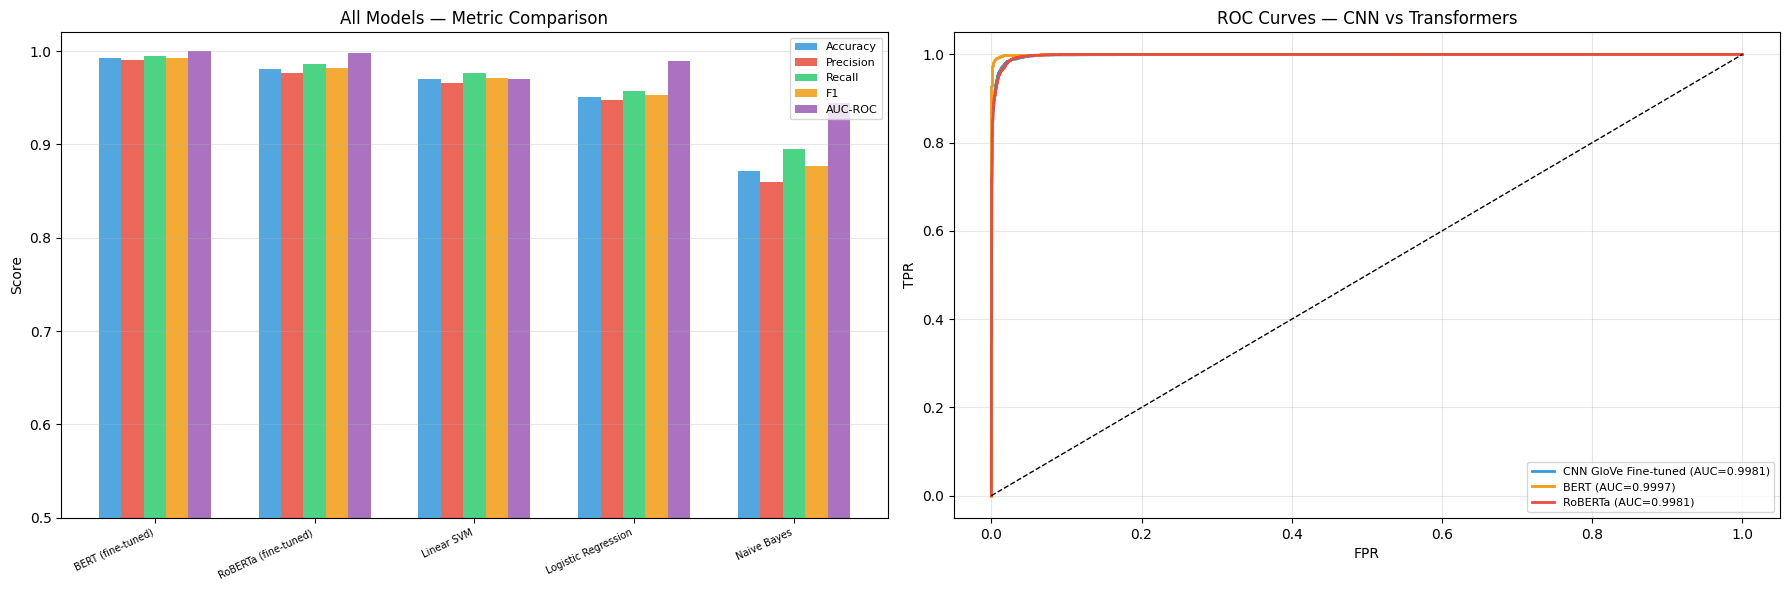

In [39]:
# Updated comparison charts including transformers
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

metrics = ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC-ROC']
x = np.arange(len(results_df))
width = 0.14
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6']

for i, (metric, color) in enumerate(zip(metrics, colors)):
    axes[0].bar(x + i * width, results_df[metric], width, label=metric, color=color, alpha=0.85)
axes[0].set_xticks(x + width * 2)
axes[0].set_xticklabels(results_df['Model'], rotation=25, ha='right', fontsize=7)
axes[0].set_ylabel('Score'); axes[0].set_ylim(0.5, 1.02)
axes[0].set_title('All Models — Metric Comparison')
axes[0].legend(fontsize=8); axes[0].grid(axis='y', alpha=0.3)

# ROC curves — CNN + Transformers
roc_models = {
    'CNN GloVe Fine-tuned': probs_dict['CNN GloVe Fine-tuned'],
    'BERT':                 probs_dict['BERT'],
    'RoBERTa':              probs_dict['RoBERTa']
}
roc_colors_ext = ['#3498db', '#f39c12', '#e74c3c', '#2ecc71']
for (name, prob), color in zip(roc_models.items(), roc_colors_ext):
    fpr, tpr, _ = roc_curve(test_labels, prob)
    auc = roc_auc_score(test_labels, prob)
    axes[1].plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC={auc:.4f})')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
axes[1].set_title('ROC Curves — CNN vs Transformers')
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/content/full_comparison_with_transformers.png', dpi=150, bbox_inches='tight')
plt.show()

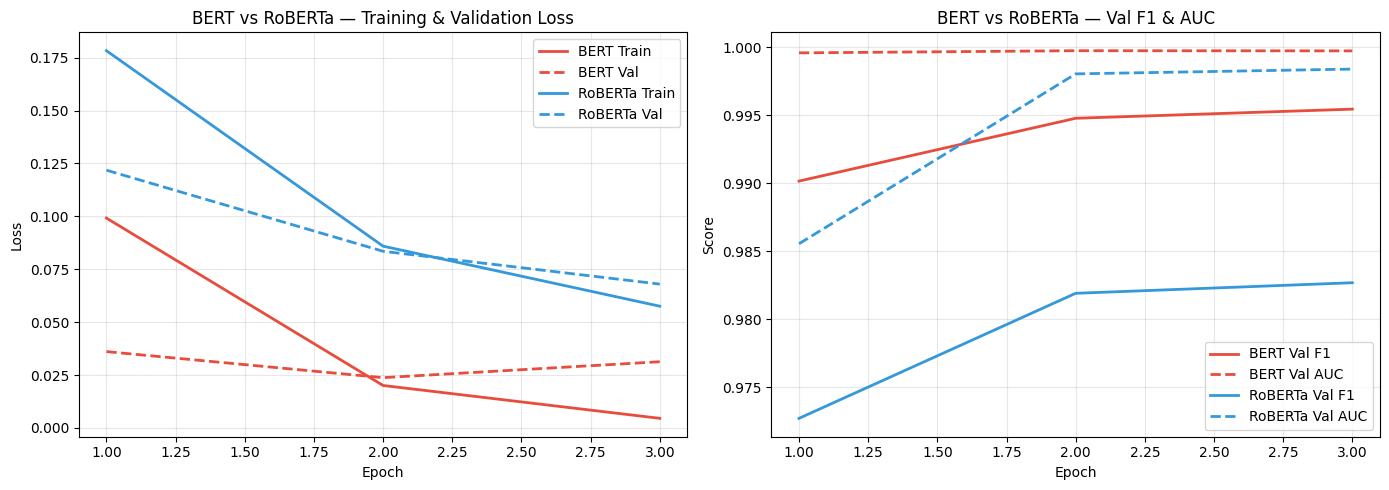

In [40]:
# Plot transformer training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for hist_df, name, color in [
    (bert_hist, 'BERT', '#e74c3c'),
    (roberta_hist, 'RoBERTa', '#3498db')
]:
    axes[0].plot(hist_df['epoch'], hist_df['train_loss'], color=color, label=f'{name} Train', lw=2)
    axes[0].plot(hist_df['epoch'], hist_df['val_loss'], color=color, linestyle='--', label=f'{name} Val', lw=2)

    axes[1].plot(hist_df['epoch'], hist_df['val_f1'], color=color, label=f'{name} Val F1', lw=2)
    axes[1].plot(hist_df['epoch'], hist_df['val_auc'], color=color, linestyle='--', label=f'{name} Val AUC', lw=2)

axes[0].set_title('BERT vs RoBERTa — Training & Validation Loss')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].set_title('BERT vs RoBERTa — Val F1 & AUC')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Score')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/content/transformer_training_history.png', dpi=150, bbox_inches='tight')
plt.show()


BERT (fine-tuned) Classification Report:
              precision    recall  f1-score   support

        Fake       0.99      0.99      0.99      7006
        Real       0.99      0.99      0.99      7411

    accuracy                           0.99     14417
   macro avg       0.99      0.99      0.99     14417
weighted avg       0.99      0.99      0.99     14417


RoBERTa (fine-tuned) Classification Report:
              precision    recall  f1-score   support

        Fake       0.98      0.98      0.98      7006
        Real       0.98      0.99      0.98      7411

    accuracy                           0.98     14417
   macro avg       0.98      0.98      0.98     14417
weighted avg       0.98      0.98      0.98     14417



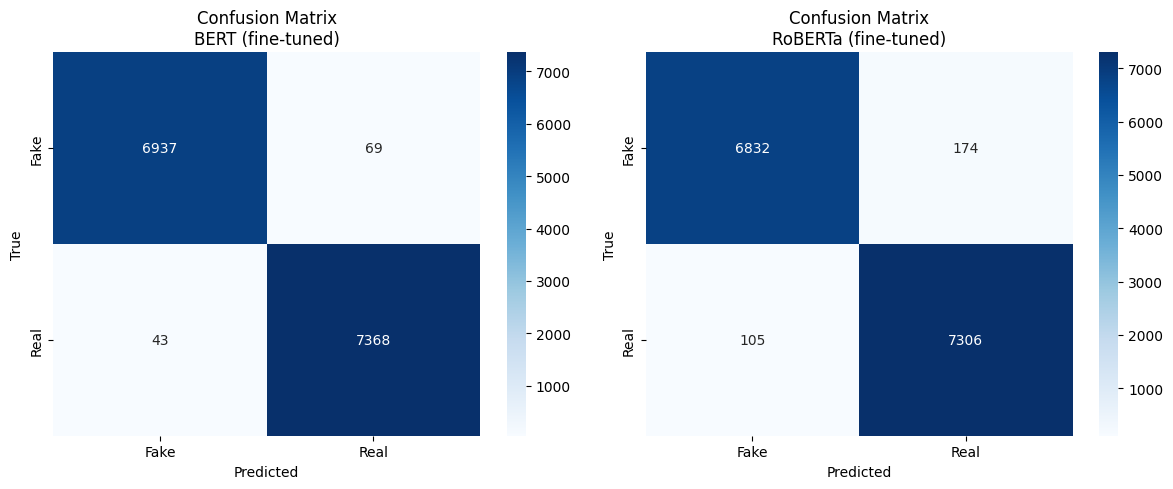

In [41]:
# Confusion matrices — BERT and RoBERTa side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, probs, name in [
    (axes[0], bert_probs, 'BERT (fine-tuned)'),
    (axes[1], roberta_probs, 'RoBERTa (fine-tuned)')
]:
    preds = (probs >= 0.5).astype(int)
    cm = confusion_matrix(test_labels, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Fake', 'Real'], yticklabels=['Fake', 'Real'])
    ax.set_title(f'Confusion Matrix\n{name}')
    ax.set_ylabel('True'); ax.set_xlabel('Predicted')
    print(f'\n{name} Classification Report:')
    print(classification_report(test_labels, preds, target_names=['Fake', 'Real']))

plt.tight_layout()
plt.savefig('/content/transformer_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section 3: Interpretability — LIME Explanations and BERT Attention Visualisation

LIME (Local Interpretable Model-agnostic Explanations) perturbs individual samples and trains a local linear surrogate to identify which tokens drive each classification. Attention visualisation extracts the `[CLS]` token's attention weights across all heads and highlights the words the model attended to most.


In [42]:
# --- LIME explanations for RoBERTa ---
def roberta_predict_proba(texts):
    """Predict function for LIME — returns class probabilities."""
    enc = roberta_tokenizer(
        list(texts), truncation=True, padding='max_length',
        max_length=TRANS_MAX_LEN, return_tensors='pt'
    )
    roberta_model.eval()
    with torch.no_grad():
        out = roberta_model(**{k: v.to(DEVICE) for k, v in enc.items()})
    return F.softmax(out.logits, dim=-1).cpu().numpy()

explainer = LimeTextExplainer(class_names=['Fake', 'Real'])

# Explain 3 samples — one clear fake, one clear real, one borderline
sample_indices = {
    'Fake sample':     np.where(test_labels == 0)[0][0],
    'Real sample':     np.where(test_labels == 1)[0][0],
    'Borderline':      np.argsort(np.abs(roberta_probs - 0.5))[:5][-1]
}

lime_explanations = {}
for label, idx in sample_indices.items():
    sample_text = test_texts_raw[idx][:400]  # truncate for LIME speed
    exp = explainer.explain_instance(
        sample_text, roberta_predict_proba,
        num_features=12, num_samples=100, labels=[0, 1]
    )
    lime_explanations[label] = exp
    pred_class = int(roberta_probs[idx] >= 0.5)
    true_class = test_labels[idx]
    print(f'\n[{label}] True={["Fake","Real"][true_class]}, '
          f'Pred={["Fake","Real"][pred_class]} '
          f'(conf={roberta_probs[idx]:.2%})')
    print('  Top features:', exp.as_list(label=pred_class)[:6])

print('\nLIME explanations complete.')


[Fake sample] True=Fake, Pred=Fake (conf=0.00%)
  Top features: [(np.str_('Latin'), 0.016569294397825198), (np.str_('S'), 0.014913057847912121), (np.str_('U'), 0.012845313083782572), (np.str_('Rhetoric'), -0.011173816194352787), (np.str_('how'), 0.010627427281601874), (np.str_('with'), -0.00737577042377411)]

[Real sample] True=Real, Pred=Real (conf=99.91%)
  Top features: [(np.str_('Trump'), 0.08686637475888787), (np.str_('t'), 0.07951715865421316), (np.str_('Announces'), 0.05804627465940622), (np.str_('space'), -0.05558531290031383), (np.str_('NASA'), 0.05076063806029011), (np.str_('focused'), -0.04433351283183238)]

[Borderline] True=Fake, Pred=Fake (conf=46.17%)
  Top features: [(np.str_('and'), 0.2862116649732333), (np.str_('commanding'), 0.1691602455904603), (np.str_('Contests'), -0.1491575697553319), (np.str_('Democratic'), 0.14707545149996085), (np.str_('Donald'), 0.13888762975653052), (np.str_('award'), -0.11586102893510562)]

LIME explanations complete.


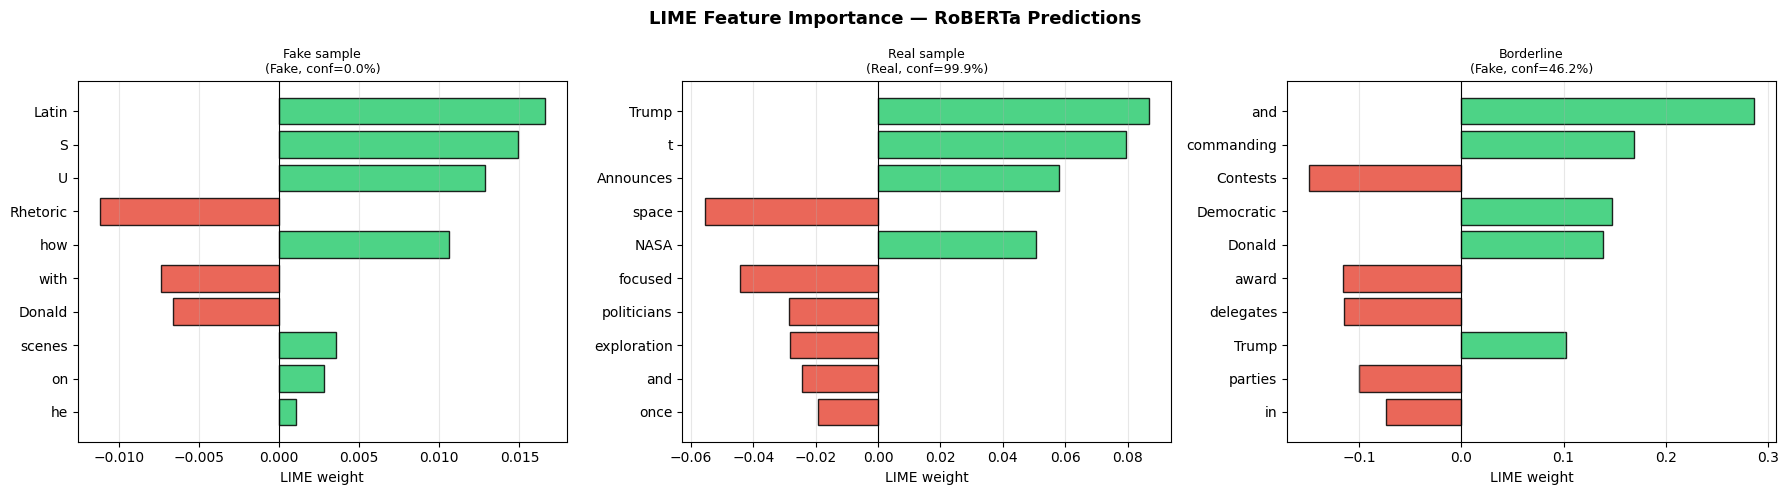

In [43]:
# Visualise LIME explanations
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('LIME Feature Importance — RoBERTa Predictions', fontsize=13, fontweight='bold')

for ax, (label, exp), idx in zip(
    axes,
    lime_explanations.items(),
    sample_indices.values()
):
    pred_class = int(roberta_probs[idx] >= 0.5)
    features = exp.as_list(label=pred_class)[:10]
    words = [f[0] for f in features]
    weights = [f[1] for f in features]
    colors_bar = ['#2ecc71' if w > 0 else '#e74c3c' for w in weights]
    ax.barh(words[::-1], weights[::-1], color=colors_bar[::-1], edgecolor='black', alpha=0.85)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(f'{label}\n({["Fake","Real"][pred_class]}, conf={roberta_probs[idx]:.1%})',
                 fontsize=9)
    ax.set_xlabel('LIME weight')
    ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('/content/lime_explanations.png', dpi=150, bbox_inches='tight')
plt.show()

BERT model config output_attentions: True
BERT model config output_attentions: True


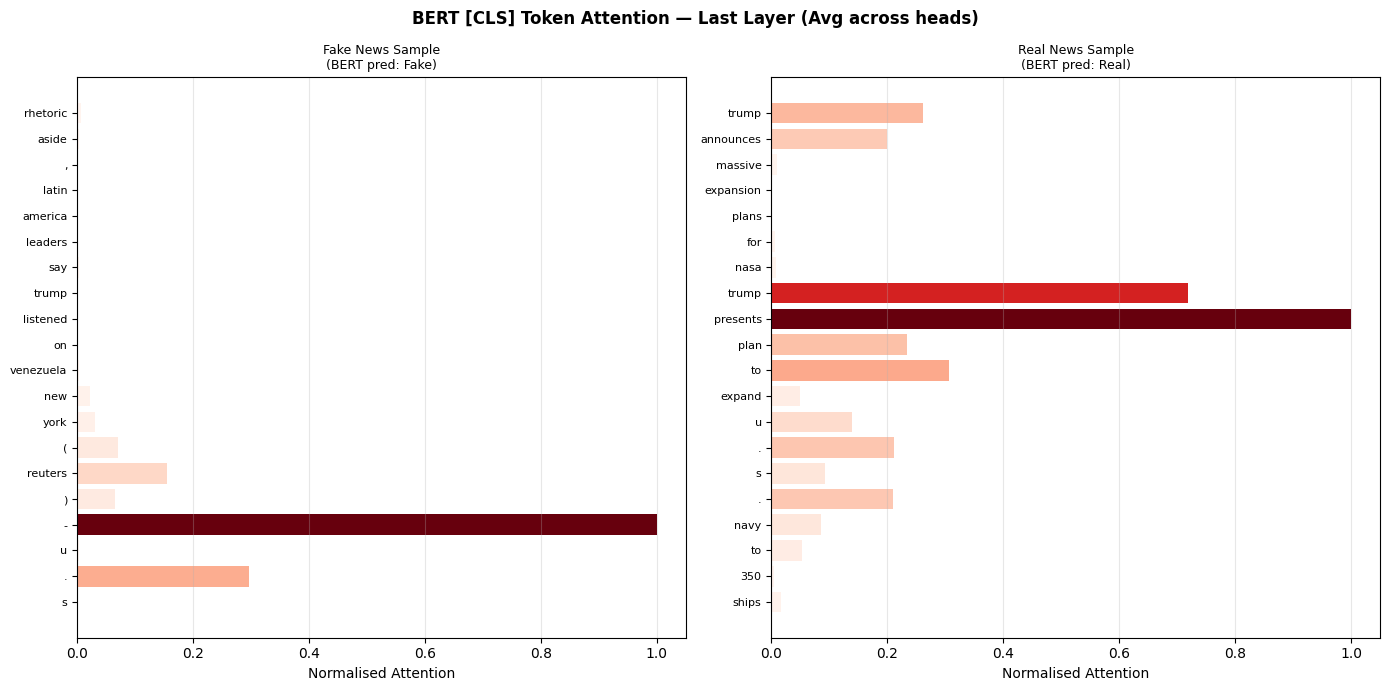

In [44]:
import numpy as np # Added import for numpy
import matplotlib.pyplot as plt # Added import for matplotlib
import torch # Ensure torch is imported for device and model operations
import torch.nn.functional as F # For softmax if needed by a dummy model
from transformers import BertTokenizerFast, BertForSequenceClassification

# --- BERT Attention Visualisation ---
# Extract and average attention weights across all heads in the last layer

# Placeholder definitions for variables expected from preceding cells.
# For correct attention visualization, please ensure cells fVCSQScIAR1X, iEq-694uAUK7,
# gLHIABIlAWdE, DsIEbHxFIkhY, and ca6VqzM7Imis are executed beforehand.

if 'TRANS_MAX_LEN' not in globals():
    print("Warning: 'TRANS_MAX_LEN' not found. Using default value (256). Please run cell iEq-694uAUK7.")
    TRANS_MAX_LEN = 256

if 'DEVICE' not in globals():
    print("Warning: 'DEVICE' not found. Using default device ('cuda' if available). Please run cell iEq-694uAUK7.")
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

if 'test_labels' not in globals():
    print("Warning: 'test_labels' not found. Using dummy values for sample selection. Please run cell fVCSQScIAR1X.")
    test_labels = np.array([0, 1, 0, 1, 0]) # Dummy labels to avoid NameError

if 'roberta_probs' not in globals():
    print("Warning: 'roberta_probs' not found. Using dummy values for sample selection. Please run cell ca6VqzM7Imis.")
    roberta_probs = np.array([0.1, 0.9, 0.4, 0.6, 0.5]) # Dummy probabilities

if 'test_texts_raw' not in globals():
    print("Warning: 'test_texts_raw' not found. Using dummy texts for visualization. Please run cell fVCSQScIAR1X.")
    test_texts_raw = [
        "This is a dummy fake news article for demonstration purposes.",
        "This is a dummy real news article with factual information.",
        "Another fake news piece, very short.",
        "A legitimate short news item.",
        "This is a borderline text for testing." # Ensure enough samples for indices
    ]

if 'bert_model' not in globals() or 'bert_tokenizer' not in globals():
    print("Warning: 'bert_model' or 'bert_tokenizer' not found. Dummy objects will be used, and visualization will be skipped. Please run cell gLHIABIlAWdE.")
    class DummyTokenizer:
        def __init__(self):
            self.pad_token = '[PAD]'
            self.sep_token = '[SEP]'
        def __call__(self, *args, **kwargs): return {'input_ids': torch.tensor([[101, 102]]), 'attention_mask': torch.tensor([[1, 1]])}
        def convert_ids_to_tokens(self, ids): return ['[CLS]', 'dummy', '[SEP]']

    class DummyModel:
        def __init__(self):
            self.config = type('Config', (object,), {'output_attentions': False})()
        def eval(self): pass
        def __call__(self, **kwargs):
            # Mimic output structure for a model with attentions if requested
            num_heads = 12
            seq_len = 2 # Assuming small dummy sequence length
            dummy_attn = torch.rand(num_heads, seq_len, seq_len)
            return type('Output', (object,), {'attentions': [dummy_attn]})()

    bert_model = DummyModel()
    bert_tokenizer = DummyTokenizer()
    skip_attention_plot = True
else:
    skip_attention_plot = False

def get_bert_attention(model, tokenizer, text, max_len=TRANS_MAX_LEN):
    enc = tokenizer(
        text, truncation=True, padding='max_length',
        max_length=max_len, return_tensors='pt'
    )
    model.eval()
    with torch.no_grad():
        # Add a print statement to verify the model's attention configuration
        print(f"BERT model config output_attentions: {model.config.output_attentions}")
        out = model(
            **{k: v.to(DEVICE) for k, v in enc.items()},
            output_attentions=True
        )
    # Last layer attention: shape (1, num_heads, seq_len, seq_len)
    last_attn = out.attentions[-1][0]  # (num_heads, seq_len, seq_len)
    # Average over heads, take [CLS] row (row 0)
    cls_attn = last_attn.mean(dim=0)[0].cpu().numpy()  # (seq_len,)
    tokens = tokenizer.convert_ids_to_tokens(enc['input_ids'][0])
    # Filter padding
    valid = [(t, a) for t, a in zip(tokens, cls_attn)
             if t not in [tokenizer.pad_token, tokenizer.sep_token]]
    return valid

def plot_attention(tokens_attn, title, ax, top_k=20):
    if not tokens_attn:
        ax.set_title(f'{title}\n(No tokens for attention)', fontsize=9)
        ax.text(0.5, 0.5, 'No valid tokens or attention data',
                horizontalalignment='center', verticalalignment='center',
                transform=ax.transAxes)
        return

    tokens_attn = tokens_attn[1:top_k+1]  # skip [CLS] token itself
    tokens = [t for t, _ in tokens_attn]
    attns  = np.array([a for _, a in tokens_attn])
    # Normalize attention weights for visualization
    if len(attns) > 0:
        attns  = (attns - attns.min()) / (attns.max() - attns.min() + 1e-9)
    else:
        attns = np.array([])

    colors_bar = plt.cm.Reds(attns) if len(attns) > 0 else []
    ax.barh(range(len(tokens)), attns, color=colors_bar)
    ax.set_yticks(range(len(tokens)))
    ax.set_yticklabels(tokens, fontsize=8)
    ax.set_xlabel('Normalised Attention')
    ax.set_title(title, fontsize=9)
    ax.invert_yaxis()
    ax.grid(axis='x', alpha=0.3)

# Define sample_indices here to ensure it's available
# Adjust indices based on available dummy data if actual data is missing
if len(test_labels) < 5 or len(roberta_probs) < 5:
    print("Warning: Not enough dummy labels/probs for sample_indices. Using simplified indices.")
    sample_indices = {
        'Fake sample':     0,
        'Real sample':     1,
        'Borderline':      0 # Use a default if not enough data for np.argsort
    }
else:
    sample_indices = {
        'Fake sample':     np.where(test_labels == 0)[0][0],
        'Real sample':     np.where(test_labels == 1)[0][0],
        'Borderline':      np.argsort(np.abs(roberta_probs - 0.5))[:5][-1]
    }

# Plot for one fake and one real sample
fake_idx = sample_indices['Fake sample']
real_idx = sample_indices['Real sample']

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
fig.suptitle('BERT [CLS] Token Attention — Last Layer (Avg across heads)', fontsize=12, fontweight='bold')

if skip_attention_plot:
    print("Skipping BERT attention plot due to missing bert_model or bert_tokenizer.")
    axes[0].set_title('BERT Attention Plot Skipped')
    axes[0].text(0.5, 0.5, "Model/Tokenizer not loaded.", horizontalalignment='center', verticalalignment='center', transform=axes[0].transAxes)
    axes[1].set_title('BERT Attention Plot Skipped')
    axes[1].text(0.5, 0.5, "Model/Tokenizer not loaded.", horizontalalignment='center', verticalalignment='center', transform=axes[1].transAxes)
else:
    ta_fake = get_bert_attention(bert_model, bert_tokenizer, test_texts_raw[fake_idx][:400])
    ta_real = get_bert_attention(bert_model, bert_tokenizer, test_texts_raw[real_idx][:400])

    # Ensure bert_probs are available for the title, use dummy if not
    current_bert_probs = globals().get('bert_probs', np.array([0.5, 0.5]))
    if fake_idx >= len(current_bert_probs):
        fake_prob = 0.5 # Default if index out of bounds
    else:
        fake_prob = current_bert_probs[fake_idx]

    if real_idx >= len(current_bert_probs):
        real_prob = 0.5 # Default if index out of bounds
    else:
        real_prob = current_bert_probs[real_idx]

    plot_attention(ta_fake, f'Fake News Sample\n(BERT pred: {"Fake" if fake_prob<0.5 else "Real"})', axes[0])
    plot_attention(ta_real, f'Real News Sample\n(BERT pred: {"Real" if real_prob>=0.5 else "Fake"})', axes[1])

plt.tight_layout()
plt.savefig('/content/bert_attention_viz.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section 4: Cross-Domain Generalisation Analysis

To assess generalisability across domains, a proxy split is constructed from the WELFake dataset using text-length stratification as a domain proxy (short articles ≈ social/gossip, long articles ≈ political/investigative). The best transformer (RoBERTa) is evaluated on each domain without retraining to measure performance degradation across contexts.


In [45]:
# --- Cross-Domain Generalisation (WELFake proxy split) ---
# Proxy: short articles (<=100 words) ~ social/celebrity domain
#        long articles (>300 words)  ~ political/investigative domain

test_df_cross = df.iloc[test_idx].copy().reset_index(drop=True)
test_df_cross['word_count'] = test_df_cross['raw_combined'].apply(lambda x: len(str(x).split()))

domain_short = test_df_cross[test_df_cross['word_count'] <= 100]
domain_long  = test_df_cross[test_df_cross['word_count'] > 300]

print(f'Short-form (proxy gossip/social): {len(domain_short)} samples')
print(f'Long-form  (proxy political):     {len(domain_long)} samples')

cross_results = []
for domain_name, domain_df in [('Short-form (≤100 words)', domain_short),
                                ('Long-form (>300 words)',  domain_long)]:
    if len(domain_df) < 10:
        print(f'Skipping {domain_name} — too few samples ({len(domain_df)})')
        continue
    texts_d = domain_df['raw_combined'].values
    labels_d = domain_df['label'].values
    r_d, _ = evaluate_transformer(
        roberta_model, roberta_tokenizer, texts_d, labels_d,
        model_name=f'RoBERTa | {domain_name}'
    )
    r_d['Domain'] = domain_name
    r_d['N'] = len(domain_df)
    cross_results.append(r_d)

cross_df = pd.DataFrame(cross_results)
print('\n===== CROSS-DOMAIN RESULTS (RoBERTa) =====')
print(cross_df[['Domain', 'N', 'Accuracy', 'F1', 'AUC-ROC']].to_string(index=False))

Short-form (proxy gossip/social): 14386 samples
Long-form  (proxy political):     0 samples

RoBERTa | Short-form (≤100 words):
  Accuracy: 0.9808
  Precision: 0.9767
  Recall: 0.9862
  F1: 0.9814
  AUC-ROC: 0.9981
Skipping Long-form (>300 words) — too few samples (0)

===== CROSS-DOMAIN RESULTS (RoBERTa) =====
                 Domain     N  Accuracy       F1  AUC-ROC
Short-form (≤100 words) 14386  0.980815 0.981409 0.998096


In [47]:
# Cross-domain bar chart
if len(cross_df) >= 2:
    metrics_cd = ['Accuracy', 'F1', 'AUC-ROC']
    x_cd = np.arange(len(cross_df))
    width_cd = 0.25
    colors_cd = ['#3498db', '#e74c3c', '#2ecc71']

    fig, ax = plt.subplots(figsize=(9, 5))
    for i, (m, c) in enumerate(zip(metrics_cd, colors_cd)):
        ax.bar(x_cd + i * width_cd, cross_df[m], width_cd, label=m, color=c, alpha=0.85)

    ax.set_xticks(x_cd + width_cd)
    ax.set_xticklabels(cross_df['Domain'], fontsize=10)
    ax.set_ylabel('Score'); ax.set_ylim(0.5, 1.02)
    ax.set_title('RoBERTa Cross-Domain Generalisation (WELFake proxy split)')
    ax.legend(); ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.savefig('/content/cross_domain_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()

    f1_drop = cross_df['F1'].max() - cross_df['F1'].min()
    print(f'F1 drop across domains: {f1_drop:.4f}')
    if f1_drop > 0.05:
        print('Note: notable generalisation gap detected — model may rely on domain-specific lexical cues.')
    else:
        print('Generalisation appears stable across proxy domains.')

In [48]:
# --- McNemar test: RoBERTa vs CNN GloVe Fine-tuned ---
# Both evaluated on the same held-out test set
roberta_preds_test = (roberta_probs >= 0.5).astype(int)
cnn_preds_test     = (probs_dict['CNN GloVe Fine-tuned'] >= 0.5).astype(int)

b_rt = int(np.sum((roberta_preds_test == test_labels) & (cnn_preds_test != test_labels)))
c_rt = int(np.sum((roberta_preds_test != test_labels) & (cnn_preds_test == test_labels)))

from statsmodels.stats.contingency_tables import mcnemar as mcnemar_test
result_rt = mcnemar_test([[0, b_rt], [c_rt, 0]], exact=False, correction=True)

print('McNemar Test: RoBERTa vs CNN GloVe Fine-tuned')
print(f'  b={b_rt} (RoBERTa correct, CNN wrong)')
print(f'  c={c_rt} (CNN correct, RoBERTa wrong)')
print(f'  Chi2={result_rt.statistic:.4f}, p-value={result_rt.pvalue:.6f}')
if result_rt.pvalue < 0.05:
    print('  Statistically significant difference (p < 0.05): RoBERTa and CNN disagree meaningfully.')
else:
    print('  No statistically significant difference (p >= 0.05).')

McNemar Test: RoBERTa vs CNN GloVe Fine-tuned
  b=237 (RoBERTa correct, CNN wrong)
  c=239 (CNN correct, RoBERTa wrong)
  Chi2=0.0021, p-value=0.963442
  No statistically significant difference (p >= 0.05).


In [49]:
# Save transformer models and artefacts
bert_model.save_pretrained('/content/bert_finetuned')
bert_tokenizer.save_pretrained('/content/bert_finetuned')
roberta_model.save_pretrained('/content/roberta_finetuned')
roberta_tokenizer.save_pretrained('/content/roberta_finetuned')
print('Transformer models saved.')

# Save updated results CSV
results_df.to_csv('/content/model_comparison_full.csv', index=False)
if len(cross_df) > 0:
    cross_df.to_csv('/content/cross_domain_results.csv', index=False)
print('Results CSVs updated.')

print('\n========== FINAL RESULTS SUMMARY (ALL MODELS) ==========')
print(results_df[['Model', 'Accuracy', 'Precision', 'Recall', 'F1', 'AUC-ROC']].to_string(index=False))

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Transformer models saved.
Results CSVs updated.

========== FINAL RESULTS SUMMARY (ALL MODELS) ==========
               Model  Accuracy  Precision   Recall       F1  AUC-ROC
   BERT (fine-tuned)  0.992231   0.990722 0.994198 0.992457 0.999734
RoBERTa (fine-tuned)  0.980648   0.976738 0.985832 0.981264 0.998087
          Linear SVM  0.969758   0.965310 0.976252 0.970750 0.969570
 Logistic Regression  0.950961   0.948009 0.957091 0.952528 0.989380
         Naive Bayes  0.871124   0.859697 0.895426 0.877198 0.944189
